## Thunderstorm Development Index Tutorial
This notebook demonstrates how to download HRRR model data, process key atmospheric variables, and prepare inputs for a Thunderstorm Development Index.

By the end of this notebook, you will:
- Know our selected variable weights.
- Plot desired variables.
- Understand the creation of our index.

## 1. Import Required Libraries

We begin by importing all necessary Python libraries for data access, processing, and visualization.

In [9]:
# Import statements
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from metpy.calc import lat_lon_grid_deltas
import os
from herbie import Herbie, FastHerbie
import dask

## 2. Define Data Configuration

We specify:
- Model type (HRRR)
- Forecast hours

In [10]:
#Date range for FastHerbie
DATES = pd.date_range(
    start="2026-04-20 00:00",
    periods=48,
    freq="1h",
)

# Create a range of forecast lead times
fxx = list(range(0, 24))

DATES

DatetimeIndex(['2026-04-20 00:00:00', '2026-04-20 01:00:00',
               '2026-04-20 02:00:00', '2026-04-20 03:00:00',
               '2026-04-20 04:00:00', '2026-04-20 05:00:00',
               '2026-04-20 06:00:00', '2026-04-20 07:00:00',
               '2026-04-20 08:00:00', '2026-04-20 09:00:00',
               '2026-04-20 10:00:00', '2026-04-20 11:00:00',
               '2026-04-20 12:00:00', '2026-04-20 13:00:00',
               '2026-04-20 14:00:00', '2026-04-20 15:00:00',
               '2026-04-20 16:00:00', '2026-04-20 17:00:00',
               '2026-04-20 18:00:00', '2026-04-20 19:00:00',
               '2026-04-20 20:00:00', '2026-04-20 21:00:00',
               '2026-04-20 22:00:00', '2026-04-20 23:00:00',
               '2026-04-21 00:00:00', '2026-04-21 01:00:00',
               '2026-04-21 02:00:00', '2026-04-21 03:00:00',
               '2026-04-21 04:00:00', '2026-04-21 05:00:00',
               '2026-04-21 06:00:00', '2026-04-21 07:00:00',
               '2026-04-

In [11]:
# Save the files with a variable of your choice
data = 'tutorial.nc'
winds = 'tutorialwinds.nc'

In [12]:
ds1 = xr.open_mfdataset(data)
ds2 = xr.open_mfdataset(winds)

sh: 1: getfattr: not found
sh: 1: getfattr: not found


## 3. Merging Multiple Data Files

After plenty of troubleshooting, we realized our u and v wind data wasn't truly being saved.  We had to make two runs and then merge them so that we would have a single dataset that we could maneuver better with.


In [13]:
# Merged function of the two xarray dataset to combine into NetCDF
ds_merge_tutorial = xr.merge([ds1,ds2], compat = 'override')

In [14]:
# Printed out merged xarray dataset - notice in the data varaibles section it now has all the varaible listed you want for the index
ds_merge_tutorial

<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2026-04-15 ... 2026-0...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B dask.array<chunksize=(49,), meta=np.ndarray>
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    longitude          (y, x) float64 15MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (valid_time, y, x) float32 373MB dask.array<chunksize=(49, 1059, 1799), meta=np.ndarray>
    d2m                (valid_time, y, x) float32 373MB dask.array<chunksize=(49, 1059, 1799), meta=np.ndarray>
    cape               (valid_time, y, x) float32 373MB dask.array<chunksize=(49, 1059, 1799), meta=np.ndarray>
    cin                (valid_time, y, x) float32 373MB dask.array<chunksize=(49, 1059, 1799), meta=np.ndarray>
    tcc                (valid_time, y, x) float32 373MB dask.array<chunksize=(49, 1059, 1799), meta=np.ndarray>
    u10                (valid_time, y, x) float32 373MB dask.array<chunksize=(49, 1059, 1799), meta=np.ndarray>
    v10                (valid_time, y, x) float32 373MB dask.array<chunksize=(49, 1059, 1799), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-30T18:26 GRIB to CDM+CF via cfgrib-0.9.1...

In [15]:
# Choose one time index (you can change this later)
fcst = ds_merge_tutorial.isel(valid_time=48)

# Extract initialization and valid times
init_time = pd.to_datetime(ds_merge_tutorial.time.values)
valid_time = pd.to_datetime(fcst.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

# Print out initial and valid times
print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Apr 15 2026
Valid Time: 00Z Apr 17 2026


In [16]:
# Extract 10-meter wind components and compute wind speed magnitude
u10 = fcst['u10']
v10 = fcst['v10']
wind_speed = np.sqrt(u10**2 + v10**2)

## 4. Index Generation:

Below is our index, where we have 6 variables, scaled between 0-100, where 0 is the least likely to create severe weather, and 100 with high chances to create severe weather.

We determined that these values had the highest chance to create severe weather across our variables:

# Best Possible conditions for thunderstorm:
- 2 meter Temperature: 60-90 °F
- 2 meter Dewpoint: 55-75°F 
- Convergence of low-level winds (lift):
- CAPE: 1-2500 J/kg
- CIN: >50 J/kg
- Total Cloud Cover: 40-100%

We determined that these values had the lowest chance to create severe weather:

# Worst Possible conditions for thunderstorm:
- 2 meter Temperature: <60°F and >90°F
- 2 meter Dewpoint: <55°F 
- Convergence of low-level winds (lift): <20 
- CAPE: 0 J/kg
- CIN: 50-200 J/kg
- Total Cloud Cover: <40%


We then tested many combinations of variable weights, with this set of weights being our final selection:

# Index Weights:
- 2 meter Temperature: 15%
- 2 meter Dewpoint:25%
- Convergence of low-level winds (lift):5%
- CAPE: 30%
- CIN: 20%
- Total Cloud Cover: 5%

This was not what we would have originally selected for our index, as we expected convergence of low-level winds to be very important to thunderstorm creation.  While that may be true, there is so much convergence happening across the country, that it muddled up our results, making most of the country very likely to experience severe weather.

In [17]:
# Convert temperatures to Fahrenheit
temp_f = (fcst['t2m'] - 273.15) * 9/5 + 32
dewpt_f = (fcst['d2m'] - 273.15) * 9/5 + 32

cape = fcst['cape']
cin = fcst['cin']
cloud = fcst['tcc'] * 100

# Compute dx and dy from lat/lon
dx, dy = lat_lon_grid_deltas(fcst['longitude'].values, fcst['latitude'].values)

# Compute convergence (negative divergence)
convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)

# Define function for Threat Index
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):

    # Temperature (best 60–90°F)
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)

    # Dewpoint (logistic growth)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))

    # CAPE (exponential growth)
    cape_index = 100 * (1 - np.exp(-cape / 1000))

    # CIN (inverse exponential decay)
    cin_index = 100 * np.exp(-np.abs(cin) / 100)

    # Cloud cover (logistic)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))

    # Convergence (scaled)
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

     # Weighted Index Calculation
    index = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)

    return index

# Printed out index in xarray
index = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)
index

/tmp/ipykernel_3612951/609753758.py:13: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)


<xarray.DataArray (y: 1059, x: 1799)> Size: 15MB
dask.array<add, shape=(1059, 1799), dtype=float64, chunksize=(1059, 1799), chunktype=numpy.ndarray>
Coordinates:
    time               datetime64[ns] 8B 2026-04-15
    step               timedelta64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    heightAboveGround  float64 8B 2.0
    latitude           (y, x) float64 15MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    longitude          (y, x) float64 15MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    valid_time         datetime64[ns] 8B 2026-04-17
    surface            float64 8B 0.0
    atmosphere         float64 8B 0.0
Dimensions without coordinates: y, x
Attributes: (12/26)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1905141
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            lambert
    GRIB_uvRelativeToGrid:                    1
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   21.138123
    GRIB_latitudeOfSouthernPoleInDegrees:     0.0
    GRIB_longitudeOfFirstGridPointInDegrees:  237.280472
    GRIB_longitudeOfSouthernPoleInDegrees:    0.0
    GRIB_missingValue:                        3.4028234663852886e+38
    standard_name:                            unknown

## 5. How we scaled our variables.

We made complex formulas for each variable to scale them between 0 and 100 for their impact. We used Desmos to accurately create formulas.

- Temperature: y=100*e^{-((x-75)^{2}/200)}
- Dewpoint: y=100/(1+e^{-0.2(x-60)})
- Convergence: y = (C+D+30)/60
- CAPE: y=100*(1-e^{-x/1000})
- CIN: y=100*e^{-x/100}
- Cloud: y=100/(1+e^{-0.1(x-50)})

These formulas were the structure behind our index, where all of our values had the same range and could be consistently compared and plotted.


In [19]:
# CONUS Map Function
def make_conus_ax(ax):

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return ax

# Set bounds for index map
bounds = np.linspace(0, 100, 101)

# Use BoundaryNorm to force exact colorbar edges
norm = mcolors.BoundaryNorm(bounds, ncolors=256)

def make_layout():
    fig, axes = plt.subplot_mosaic(
        [
            ["main", "main", "ax1", "ax2"],
            ["main", "main", "ax3", "ax4"],
            ["ax5",  "ax5",  "ax6", "ax6"],
        ],
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(20, 12),
        layout="constrained"
    )

    ax_main = axes["main"]
    ax1 = axes["ax1"]
    ax2 = axes["ax2"]
    ax3 = axes["ax3"]
    ax4 = axes["ax4"]
    ax5 = axes["ax5"]
    ax6 = axes["ax6"]

    for ax in [ax_main, ax1, ax2, ax3, ax4, ax5, ax6]:
        make_conus_ax(ax)
        
    return (fig, axes["main"],axes["ax1"], axes["ax2"],axes["ax3"], axes["ax4"],axes["ax5"], axes["ax6"])

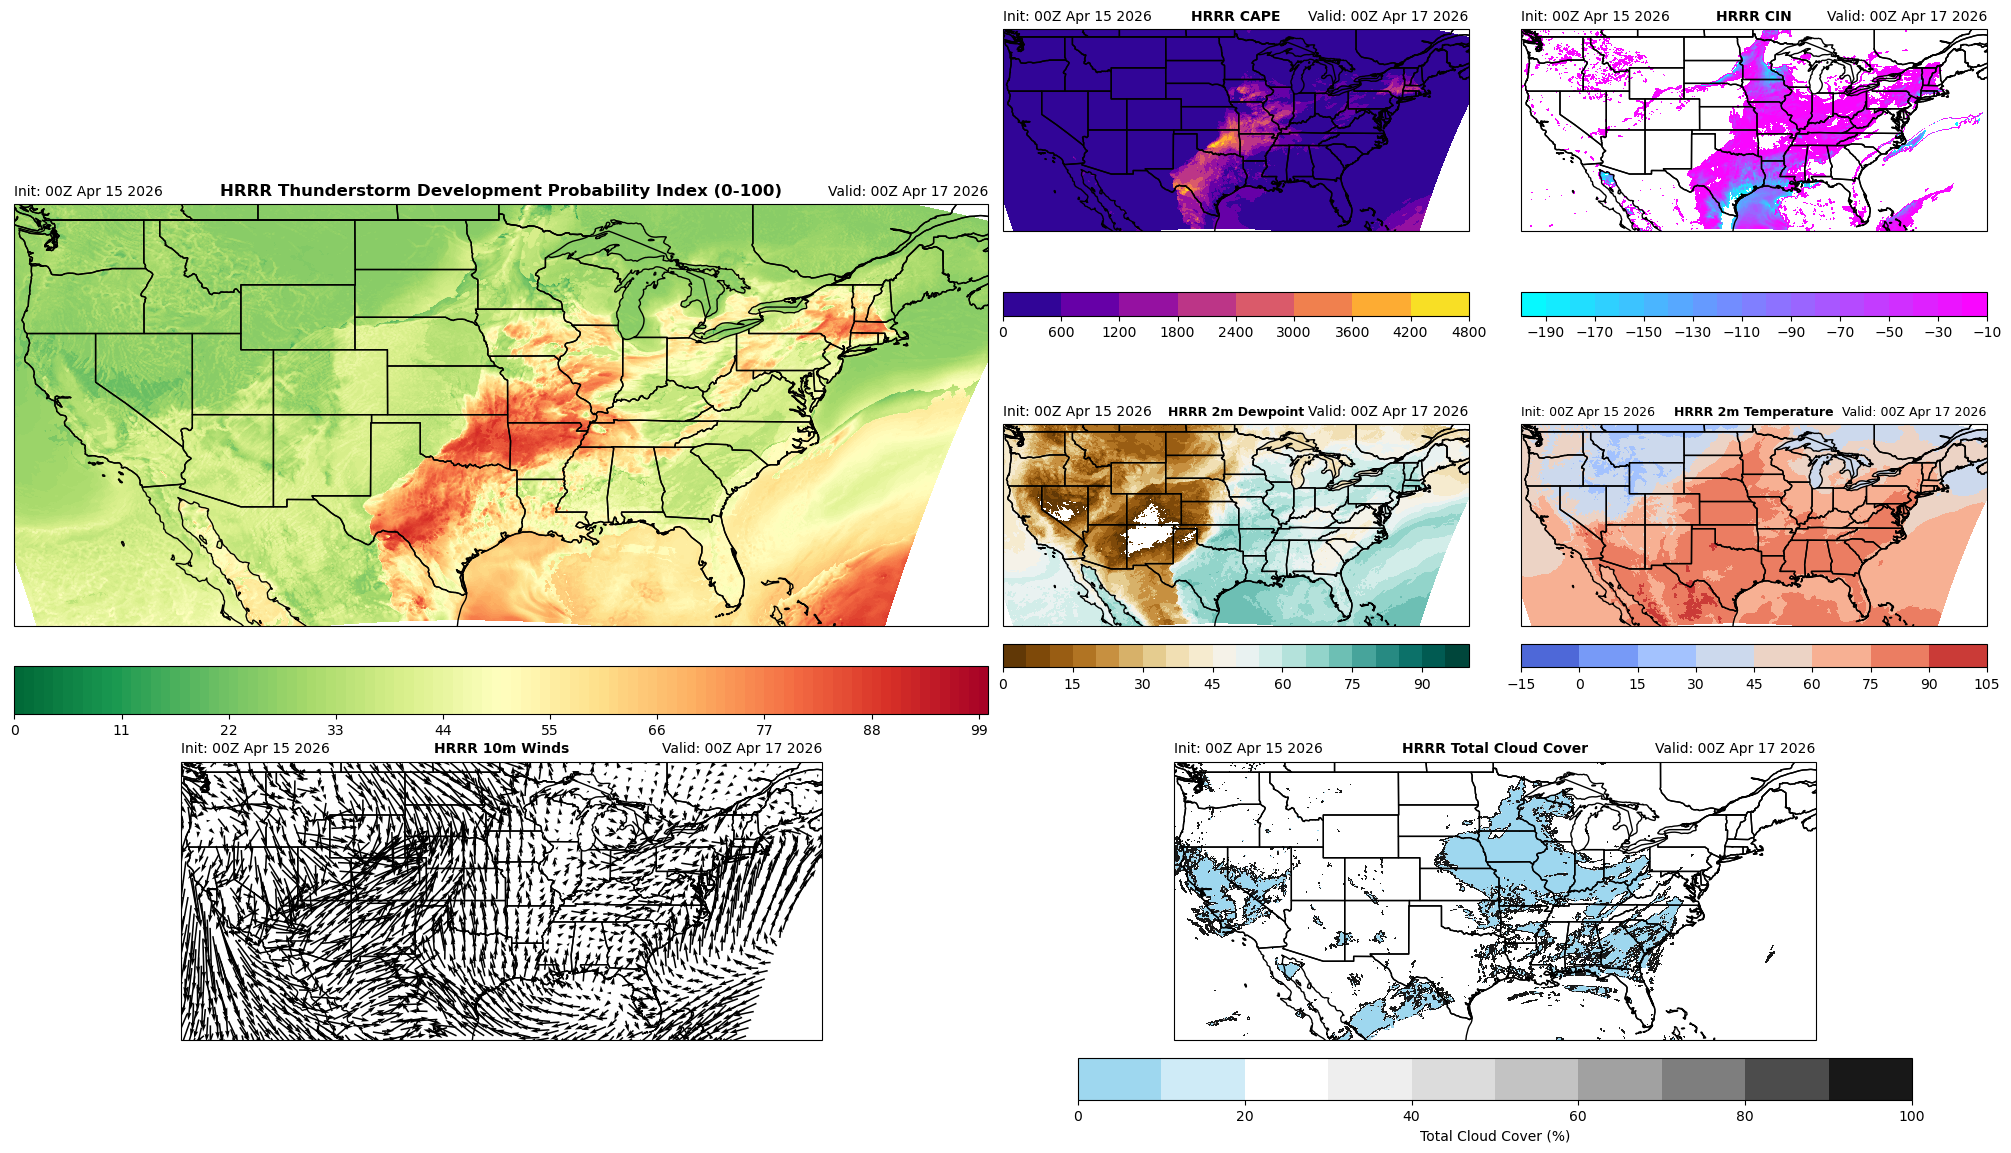

In [22]:
fig, ax_main, ax1, ax2, ax3, ax4, ax5, ax6 = make_layout()

# --- Main Map (Threat Index) ---
cf = ax_main.contourf(ds_merge_tutorial.longitude, ds_merge_tutorial.latitude, index, levels=bounds,
                      cmap='RdYlGn_r',
                      transform=ccrs.PlateCarree())
cbar = plt.colorbar(cf, ax=ax_main, orientation='horizontal', pad=0.05)
ax_main.set_title("HRRR Thunderstorm Development Probability Index (0-100)", loc='center', fontweight='bold')
ax_main.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax_main.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 1 (CAPE) ---
cape = fcst['cape']
cf1 = ax1.contourf(ds_merge_tutorial.longitude, ds_merge_tutorial.latitude, cape,
                   transform=ccrs.PlateCarree(), cmap='plasma')
plt.colorbar(cf1, ax=ax1, orientation='horizontal', pad=0.01)
ax1.set_title("HRRR CAPE", loc='center', fontweight='bold', fontsize=10)
ax1.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax1.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)


# --- Map 2 (CIN)---

cin = fcst['cin']
cf2 = ax2.contourf(ds_merge_tutorial.longitude, ds_merge_tutorial.latitude, cin, levels = np.arange(-200, 0, 10),
                   transform=ccrs.PlateCarree(), cmap='cool')
plt.colorbar(cf2, ax=ax2, orientation='horizontal', pad=0.01)
ax2.set_title("HRRR CIN", loc='center', fontweight='bold', fontsize=10)
ax2.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax2.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 3 (2m Dewpoint)---
dew = (fcst['d2m'] - 273.15) * 9/5 + 32
cf3 = ax3.contourf(ds_merge_tutorial.longitude, ds_merge_tutorial.latitude, dew, levels = np.arange(0, 105, 5),
                   transform=ccrs.PlateCarree(), cmap='BrBG')
plt.colorbar(cf3, ax=ax3, orientation='horizontal', pad=0.05)
ax3.set_title("HRRR 2m Dewpoint", loc='center', fontweight='bold', fontsize=9)
ax3.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax3.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 4 (2m Temperature)---
temp = (fcst['t2m'] - 273.15) * 9/5 + 32
cf4 = ax4.contourf(ds_merge_tutorial.longitude, ds_merge_tutorial.latitude, temp,
                   transform=ccrs.PlateCarree(), cmap='coolwarm')
plt.colorbar(cf4, ax=ax4, orientation='horizontal', pad=0.05)
ax4.set_title("HRRR 2m Temperature", loc='center', fontweight='bold', fontsize=9)
ax4.set_title(f"Init: {init_str}",   loc='left', fontsize=9)
ax4.set_title(f"Valid: {valid_str}", loc='right', fontsize=9)

# --- Map 5 (10m Wind Vectors) ---
skip = 30
cf5 = ax5.quiver(ds_merge_tutorial.longitude[::skip, ::skip],
          ds_merge_tutorial.latitude[::skip, ::skip],
          u10[::skip, ::skip],
          v10[::skip, ::skip],
          transform=ccrs.PlateCarree(),
          scale=200)

ax5.set_title("HRRR 10m Winds", loc='center', fontweight='bold', fontsize=10)
ax5.set_title(f"Init: {init_str}", loc='left', fontsize=10)
ax5.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 6 (Cloud Cover) ---

cloud_colors = ['skyblue', 'white', 'lightgray', 'gray', 'black']
cloud_cmap = LinearSegmentedColormap.from_list('clouds', cloud_colors)

cloud = fcst['tcc'] * 100  # convert to %

cf6 = ax6.contourf(ds_merge_tutorial.longitude, ds_merge_tutorial.latitude, cloud,
                 levels=np.arange(0, 101, 10),
                 cmap=cloud_cmap,
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf6, ax=ax6, orientation='horizontal', pad=0.05)
cbar.set_label('Total Cloud Cover (%)')
ax6.set_title("HRRR Total Cloud Cover", loc='center', fontweight='bold', fontsize=10)
ax6.set_title(f"Init: {init_str}", loc='left', fontsize=10)
ax6.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

plt.show()

## 6. How our index works.

Each of these plots are a different variables values across the country at a given hour.  The top left plot is our index graph, showing the highest and lowest likelihood areas of experiencing severe weather.